# Plot VarNet Inference Results
This notebook visualizes VarNet reconstructions from `/home/paula/SDF_intro/outputs/varnet_inference/reconstructions` and compares them to ground truth slices from `../../../../data/datasets/fastMRI/knee/multicoil_val`.

In [2]:
import matplotlib.pyplot as plt
from fastmri.pl_modules import FastMriDataModule
from collections import defaultdict

/home/paula/miniconda3/envs/mri_varnet/lib/python3.10/site-packages/lightning_lite/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [ ]:
from collections import defaultdict
from fastmri.data.transforms import UnetDataTransform

test_transform = UnetDataTransform(which_challenge="multicoil",)
dm = FastMriDataModule(
    data_path       = Path("../../../../data/datasets/fastMRI/knee"),
    challenge       = "multicoil",
    train_transform = None,
    val_transform   = test_transform,
    test_transform  = test_transform,
    test_split      = "val",
    batch_size      = 1,
    num_workers     = 4,
    )
ds = dm.test_dataloader().dataset
print(f"Dataset length: {len(ds)}")
idxs_by_vol = defaultdict(list)
for didx, sample in enumerate(ds):
    idxs_by_vol[sample[4]].append(didx)
print(f"Found {len(idxs_by_vol)} volumes in the dataset.")

In [ ]:
vol_key = 'file1000000.h5'  # use the desired volume key directly
slice_idxs = idxs_by_vol[vol_key]
print(f"Volume {vol_key} has {len(slice_idxs)} slices")

slice_idxs = sorted(slice_idxs)

fig, axs = plt.subplots(5, 6, figsize=(12, 11)) # plot first 36 slices (all)
for ax, (offset, didx) in zip(axs.ravel(), enumerate(slice_idxs)):

    ksp = ds[didx][0].squeeze()

    ax.imshow(ksp, cmap="gray")
    ax.set_title(
        f"Slice #{offset+1}",
        fontsize=8,
        pad=4
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

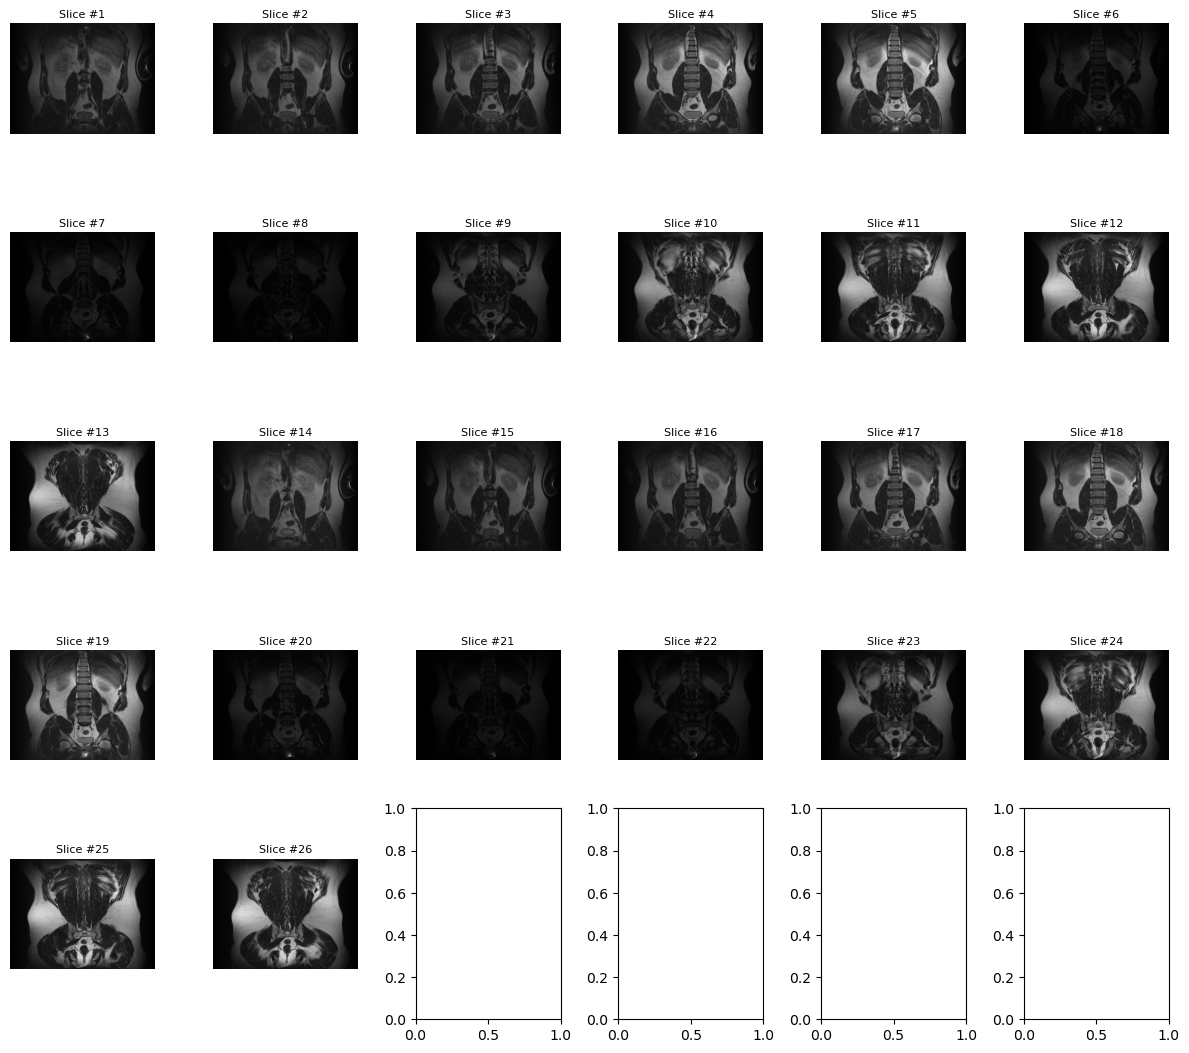

In [5]:
import h5py
with h5py.File('../../../../../data/datasets/msk_mri_h5/test_varnet/meas_MID00015_FID117913_COR_T2.h5', 'r') as f:
    reconstructions = f['reconstruction_rss'][:]  # assuming 'reconstruction' is the dataset name
fig, axs = plt.subplots(5, 6, figsize=(12, 11)) # plot first 36 slices (all)
for ax, (offset, slice_idx) in zip(axs.ravel(), enumerate(range(reconstructions.shape[0]))):

    recon = reconstructions[slice_idx].squeeze()

    ax.imshow(recon, cmap="gray")
    ax.set_title(
        f"Slice #{offset+1}",
        fontsize=8,
        pad=4
    )
    ax.axis("off")
plt.tight_layout()
plt.show()

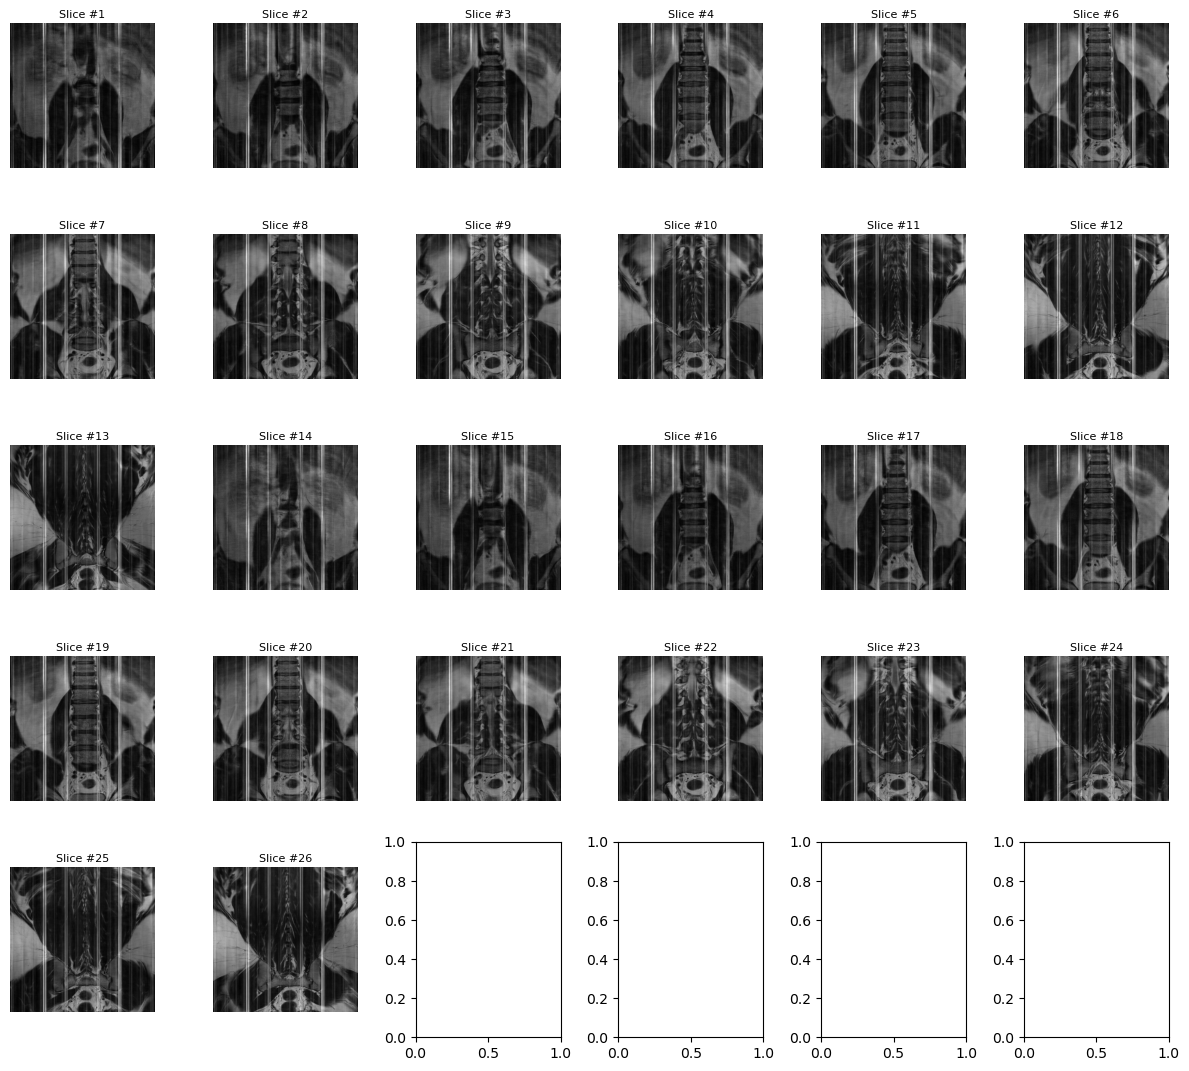

In [3]:
# get "reconstruction" and plot slices
import h5py
with h5py.File('/home/paula/msk_mri_dataset/varnet/outputs/varnet_inference/reconstructions/meas_MID00015_FID117913_COR_T2.h5', 'r') as f:
    reconstructions = f['reconstruction'][:]  # assuming 'reconstruction' is the dataset name
fig, axs = plt.subplots(5, 6, figsize=(12, 11)) # plot first 36 slices (all)
for ax, (offset, slice_idx) in zip(axs.ravel(), enumerate(range(reconstructions.shape[0]))):

    recon = reconstructions[slice_idx].squeeze()

    ax.imshow(recon, cmap="gray")
    ax.set_title(
        f"Slice #{offset+1}",
        fontsize=8,
        pad=4
    )
    ax.axis("off")
plt.tight_layout()
plt.show()